# Exercises

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})


## Exercise 1 + 2
---
- Determine the effect of stimulus sequence duration on RF estimates. To do this, repeat the above steps for different durations (5 s, 10 s, 20 s, 40 s, 80 s, 160 s, 320 s, 640 s). Compute the Pearson correlation between true and estimated RFs for each duration to quantify the accuracy of the estimator. The Pearson correlation $\mathrm{cc}$ is defined as
$$
\mathrm{cc} = \frac{\mathbf{k}_\mathrm{true}^T \hat{\mathbf{k}}}{\lVert \mathbf{k}_\mathrm{true} \rVert \lVert \hat{\mathbf{k}} \rVert}
$$
where $\lVert \cdot \rVert$ is the L2-norm (vector length).
As the response generation process is stochastic, compute the average correlation across 10 realizations for the same duration and plot the average correlation as a function of duration. How is the recording duration related to the ability to recover the true RF?

To do this, we have to do the same but create a loop for the code, see below.

- Determine the effect of response noise ($\sigma^2$) on RF estimates. Try different value for the noise variance in the simulations, e.g., 0, 2, 4, 6, 8, and 10 for a duration of 100 s. As in the previous excercise, repeatedly estimate RF parameters for each condition (10 times) but this time also plot the standard deviation of the correlations across the different runs for each condition.

Text(0, 0.5, 'y')

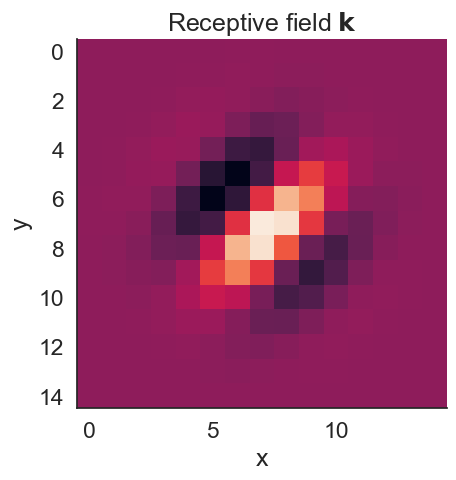

In [7]:
size = vf_size # size in pixel of our receptive field
mu = (8, 8) # center of the gabor pathc
sigma = (4,4) #size of the gabor patch
angle = 45 # orientation of the gabor patch
frequency = .085 # spatial frequency of the gabor patch
phase = 0 # pahse of the gabor pathc


xx, yy = np.meshgrid(1. + np.arange(size[0]),
                         1. + np.arange(size[1]))

# Gaussian envelope
G = np.exp(- np.power(xx - mu[0], 2) / (2. * sigma[0])
            - np.power(yy - mu[1], 2) / (2. * sigma[1]))

# spatial modulation
phi = np.deg2rad(angle)
xxr = xx * np.cos(phi)
yyr = yy * np.sin(phi)
xyr = (xxr + yyr) * 2. * np.pi * 2. * frequency
Sn = np.cos(xyr + phase)

K = G * Sn
K /= np.amax(np.abs(K))

plt.imshow(K)
plt.title(r'Receptive field $\bf{k}$')
plt.xlabel('x')
plt.ylabel('y')

In [28]:
# --- Parameters ---
durations = [5, 10, 20, 40, 80, 160, 320, 640]
n_repeats = 10
dt = 0.1
std_dev = 1
vf_size = (15, 15)
spike_rate = 5  # average firing rate

# --- Ground truth RF ---
np.random.seed(0)
K = np.random.randn(*vf_size)
K_flat_true = K.ravel()

# --- Results storage ---
avg_corrs = []

# --- Helper functions ---
def generate_inhomogeneous_poisson_spikes(lamda, dt):
    n_bins = lamda.shape[0]
    bins = np.arange(n_bins + 1) * dt
    lamda_max = np.max(lamda)
    poisson_numbers = np.random.poisson(lamda_max, size=n_bins)

    spike_times = []
    prob = lamda / lamda_max
    for i in range(n_bins):
        n = np.sum(np.random.rand(poisson_numbers[i]) < prob[i])
        n_s = int(round(n * dt))
        ts = bins[i] + np.random.rand(n_s) * dt
        spike_times.extend(ts)
    return np.asarray(spike_times)

def cost(k, spike_counts, S, alpha=1):
    ks = np.dot(k, S.T)
    lamda = np.exp(ks)
    return -np.dot(spike_counts, ks) + dt * np.sum(lamda)

def grad(k, spike_counts, S):
    ks = np.dot(k, S.T)
    lamda = np.exp(ks)
    return -np.dot(S.T, spike_counts - dt * lamda)

# --- Loop over durations ---
for duration in durations:
    corrs = []
    for repeat in range(n_repeats):
        n_bins = round(duration / dt)

        # Stimulus
        S = std_dev * np.random.randn(n_bins, vf_size[0], vf_size[1])
        S /= np.std(S) # normalizing
        S_flat = S.reshape(n_bins, -1)
        S_flat = np.hstack((S_flat, np.ones((n_bins, 1))))  # add offset

        # Flatten true RF and add offset
        K_flat = np.hstack((K_flat_true, 0.0))

        # Linear & nonlinear stage
        ks = np.dot(K_flat, S_flat.T)
        ks = np.clip(ks, -50, 50)
        lamda = np.exp(ks)

        expected_rate = np.sum(lamda * dt) / duration
        lamda *= (spike_rate / expected_rate)

        # Generate spikes and bin them
        spike_times = generate_inhomogeneous_poisson_spikes(lamda, dt)
        spike_counts = np.histogram(spike_times, bins=np.arange(n_bins + 1) * dt)[0]

        # Estimate RF using GLM
        k_STA = np.inner(S_flat.T, spike_counts) / np.sum(spike_counts)
        res = minimize(fun=cost, x0=k_STA / 10, args=(spike_counts, S_flat),
                       method='Newton-CG', jac=grad)
        K_est = res.x

        # Pearson correlation
        cc = np.inner(K.ravel(), K_est[:-1]) / (
            np.linalg.norm(K.ravel()) * np.linalg.norm(K_est[:-1])
        )
        corrs.append(cc)

    avg_cc = np.mean(corrs)
    avg_corrs.append(avg_cc)
    print(f"Duration: {duration:>4}s | Avg Pearson Corr: {avg_cc:.3f}")



C:\Users\Beheerder\AppData\Local\Temp\ipykernel_26516\1886291455.py:40: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)


Duration:    5s | Avg Pearson Corr: 0.099
Duration:   10s | Avg Pearson Corr: 0.148


C:\Users\Beheerder\AppData\Local\Temp\ipykernel_26516\1886291455.py:35: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)
C:\Users\Beheerder\AppData\Local\Temp\ipykernel_26516\1886291455.py:35: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)
C:\Users\Beheerder\AppData\Local\Temp\ipykernel_26516\1886291455.py:40: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)


Duration:   20s | Avg Pearson Corr: 0.123
Duration:   40s | Avg Pearson Corr: 0.212
Duration:   80s | Avg Pearson Corr: 0.247


C:\Users\Beheerder\AppData\Local\Temp\ipykernel_26516\1886291455.py:35: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)
C:\Users\Beheerder\AppData\Local\Temp\ipykernel_26516\1886291455.py:40: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)


Duration:  160s | Avg Pearson Corr: 0.352


C:\Users\Beheerder\AppData\Local\Temp\ipykernel_26516\1886291455.py:40: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)


Duration:  320s | Avg Pearson Corr: 0.470
Duration:  640s | Avg Pearson Corr: 0.630


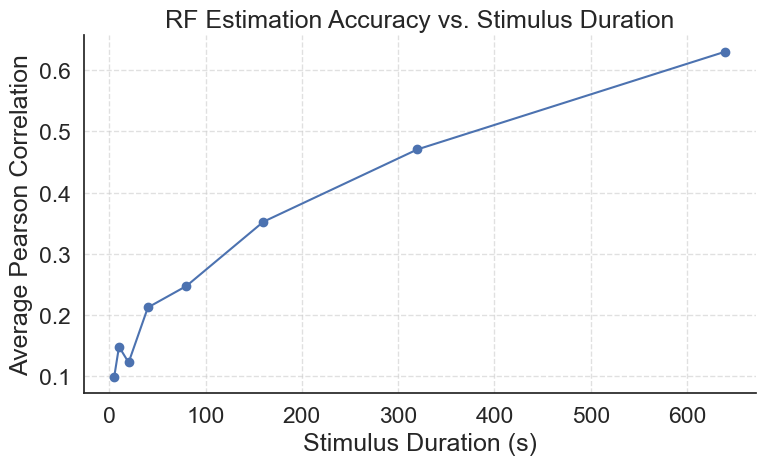

In [29]:
# --- Plotting ---
plt.figure(figsize=(8,5))
plt.plot(durations, avg_corrs, marker='o')
plt.xlabel('Stimulus Duration (s)')
plt.ylabel('Average Pearson Correlation')
plt.title('RF Estimation Accuracy vs. Stimulus Duration')
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## Exercise 3
---
Look at the analytical derivation of the log-likelihood for the poisson GLM.
Which of the terms are required for maximizing the likelihood with respect to $\mathbf{k}$ and which terms can be ignored? **Note:** due to the independence of spikes in the different bins, the likelihood can be written as $P(R | S, \mathbf{k}) = \prod_t^T P(r_t | \mathbf{s}_t, \mathbf{k})$. The log turns the product into a sum which makes life much easier. 




## Exercise 4
---
Explore the effect of the data duration and the firing rate on the goodness of fit of the Poisson GLM.

A - Generate data with durations of 10,20,50,100 and 200 seconds. Fit the model on each dataset and plot the fitted parameters.
Use the pearson correlation as a proxy of the goodness of fit, and plot it as a function of the duration of the data.

B - Fix the duration to 100s, and change the average firing rate of the simulation. How does the fit perform for different firing rates? 